In [15]:
# ============================================================
# BIOMEDICAL SIGNAL PROCESSING PRACTICE
# PROBLEMS 1 - 4
# ============================================================
# CELL 1: INSTALL REQUIRED PACKAGE
%pip install xlrd -q

# ============================================================
# CELL 2: IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Libraries loaded successfully.")
# ============================================================
# CELL 3: FILE PATHS

file1 = r"C:\Users\Therm\OneDrive\Downloads\BCI 1 Pro\F802_5Hz_50uV.xls"
file2 = r"C:\Users\Therm\OneDrive\Downloads\BCI 1 Pro\9110_5Hz_1mV.xls"
file3 = r"C:\Users\Therm\OneDrive\Downloads\BCI 1 Pro\618E_ecg_atf.xls"
file4 = r"C:\Users\Therm\OneDrive\Downloads\BCI 1 Pro\4C62_ecg_cln.xls"


Note: you may need to restart the kernel to use updated packages.
Libraries loaded successfully.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Therm\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



PROBLEM 1: LOAD AND INSPECT

Loading files...
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
All four files loaded successfully.

FIRST 10 ROWS

----------------------------------------------------------------------
File 1 - 50 uV sine wave
----------------------------------------------------------------------
 Timestamp   Voltage
     0.000 -0.121155
     0.002 -0.120239
     0.004 -0.118713
     0.006 -0.116577
     0.008 -0.112915
     0.010 -0.108032
     0.012 -0.103760
     0.014 -0.100403
     0.016 -0.093689
     0.018 -0.087280

----------------------------------------------------------------------
File 2 - 1 mV sine wave
----------------------------------------------------------------------
 Timestamp   Voltage
     0.000 -1.888428
     0.002 -1.988831
 

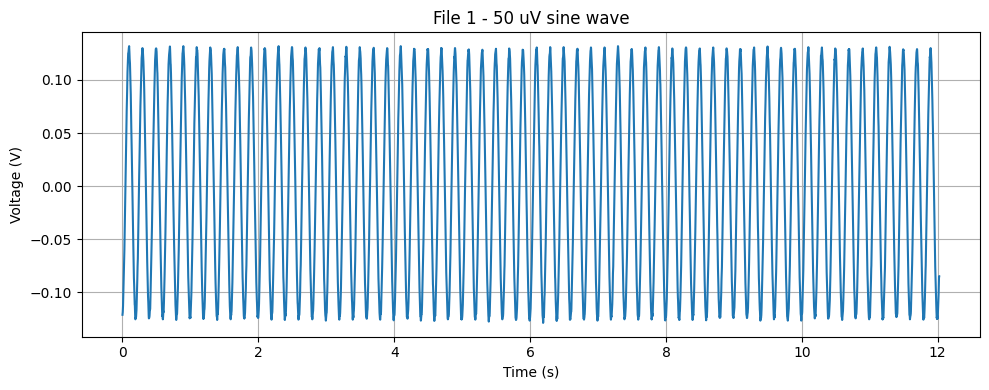

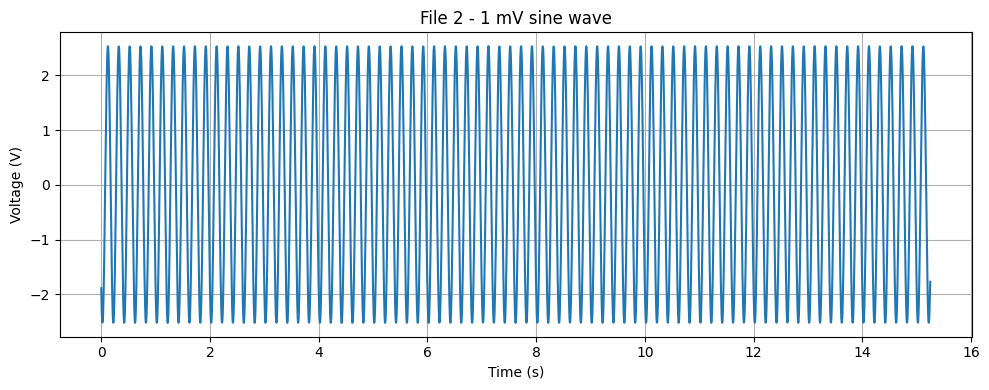

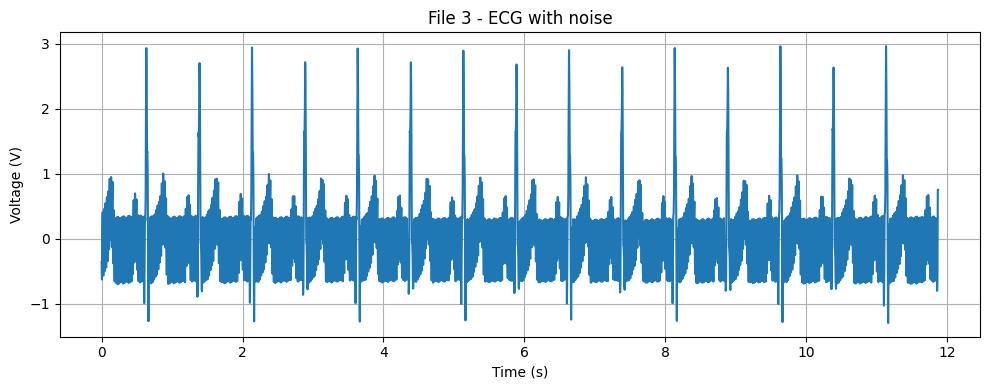

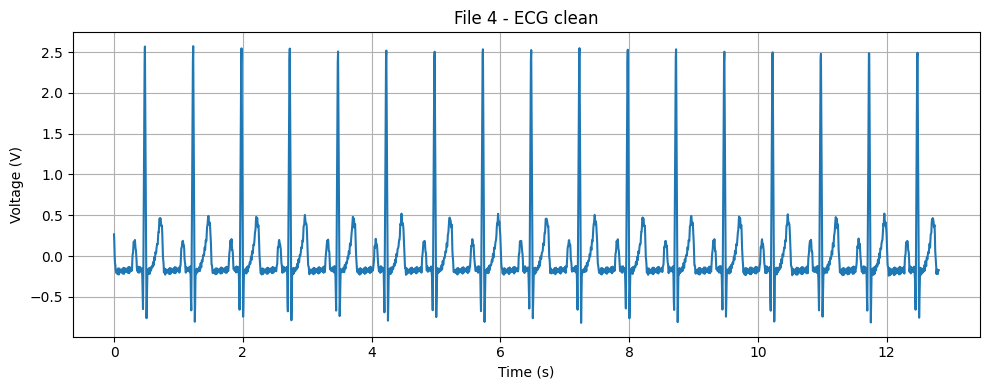



PROBLEM 2: DATA SUMMARY

File 1 - 50 uV sine wave
Minimum            : -0.128784 V
Maximum            : 0.131836 V
Mean               : 0.001598 V
Standard deviation : 0.089655 V

File 2 - 1 mV sine wave
Minimum            : -2.520752 V
Maximum            : 2.530518 V
Mean               : -0.005032 V
Standard deviation : 1.785869 V

STATISTICS FOR ALL FOUR FILES
                    File  Minimum (V)  Maximum (V)  Mean (V)  Standard Deviation (V)
File 1 - 50 uV sine wave    -0.128784     0.131836  0.001598                0.089655
 File 2 - 1 mV sine wave    -2.520752     2.530518 -0.005032                1.785869
 File 3 - ECG with noise    -1.296082     2.960205 -0.001022                0.562102
      File 4 - ECG clean    -0.818176     2.572021  0.001902                0.434829


PROBLEM 3: OVERLAY AND COMPARISON

Problem 3.1: Sine-wave overlay


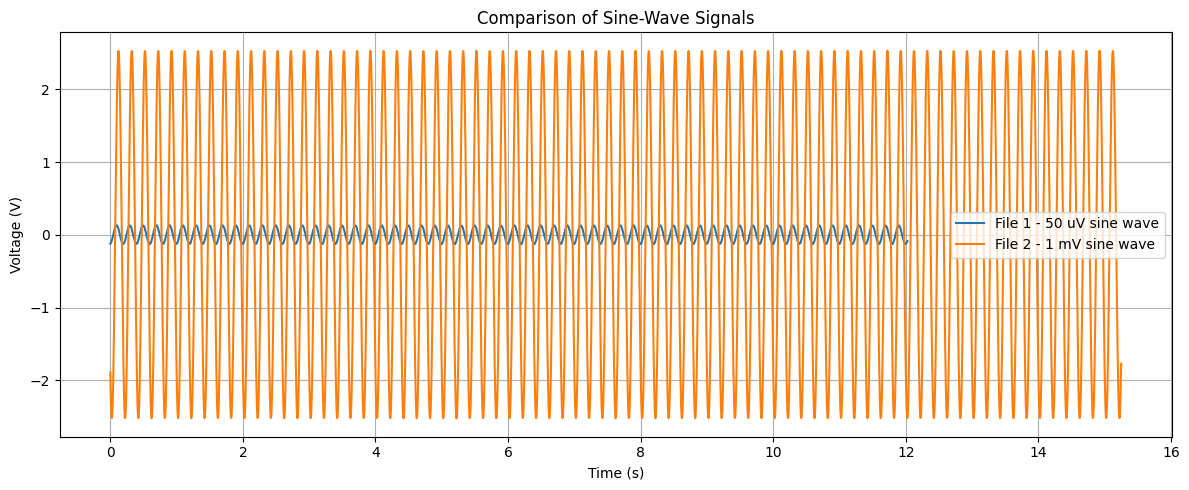


Problem 3.2: ECG noisy vs. clean


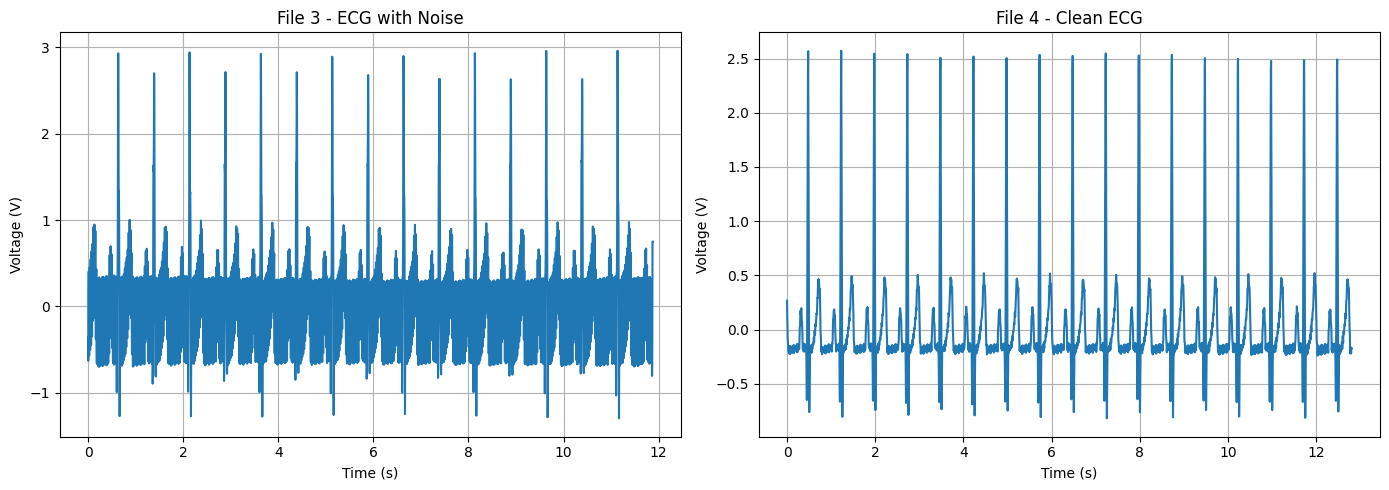


Observation:

Noisy ECGs exhibit more fluctuations and irregularities than clean ECGs.

Clean ECGs have smoother waveforms, making QRS complexes and R-peaks simpler to discern.



In [16]:
# ============================================================
# PART A
# BASIC DATA HANDLING
# PROBLEM 1
# LOAD AND INSPECT
# ============================================================
print("\n" + "=" * 70)
print("PROBLEM 1: LOAD AND INSPECT")
print("=" * 70)
# ------------------------------------------------------------
# FUNCTION TO LOAD THE .XLS FILE
def load_signal(file_path):
    """
    Load a biological signal from an Excel.xls file.

    The function recognizes the time and signal columns automatically. The algorithm examines column names before utilizing the data's numeric structure as needed.

    Parameters
-------- file_path: string
        The path to the.xls file.

    Returns
----- Pandas.DataFrame with timestamp and voltage fields.
    """

    raw = pd.read_excel(file_path,engine="xlrd",header=None)
    raw = raw.dropna(axis=0, how="all").dropna(axis=1,how="all").reset_index(drop=True)
    time_col = None
    voltage_col = None
    for col in raw.columns:
        values = raw[col].astype(str).str.strip().str.lower()
        if time_col is None:
            if values.isin(
                ["timestamp", "time", "time stamp"]
            ).any():
                time_col = col
        if voltage_col is None:
            if values.isin(
                ["voltage", "signal", "ecg"]
            ).any():

                voltage_col = col
    if time_col is None or voltage_col is None:
        for col in raw.columns:
            text = " ".join(
                raw[col].astype(str).str.lower().tolist()[:10]
            )
            if time_col is None:
                if (
                    "timestamp" in text
                    or "time" in text
                ):
                    time_col = col
            if voltage_col is None:
                if (
                    "voltage" in text
                    or "signal" in text
                    or "ecg" in text
                ):
                    voltage_col = col
    numeric_columns = []

    for col in raw.columns: numeric_values = pd.to_numeric(raw[col],errors="coerce")

    valid_count = numeric_values.notna().sum()
    if valid_count >= 10:
            numeric_columns.append(
                (col, valid_count)
            )
    if time_col is None:
        time_candidates = []
        for col, valid_count in numeric_columns:
            values = pd.to_numeric(
                raw[col],
                errors="coerce"
            ).dropna().to_numpy()
            if len(values) < 10:
                continue
            differences = np.diff(values)
            increasing_fraction = np.mean(
                differences > 0
            )
            if increasing_fraction > 0.95:
                time_candidates.append(
                    (col, valid_count)
                )
        if len(time_candidates) > 0:
            time_col = time_candidates[0][0]
    if voltage_col is None:
        voltage_candidates = []
        for col, valid_count in numeric_columns:
            if col == time_col:
                continue
            voltage_candidates.append(
                (col, valid_count)
            )
        if len(voltage_candidates) > 0:
            voltage_col = max(
                voltage_candidates,
                key=lambda x: x[1]
            )[0]
    if time_col is None or voltage_col is None:
        print("\nCould not automatically identify columns.")
        print("Raw file preview:")
        print(raw.head(15).to_string(index=False))
        raise ValueError(
            f"Could not identify time and signal columns in:\n"
            f"{file_path}"
        )
    data = pd.DataFrame({
        "Timestamp": pd.to_numeric(
            raw[time_col],
            errors="coerce"
        ),
        "Voltage": pd.to_numeric(
            raw[voltage_col],
            errors="coerce"
        )
    })
    data = data.dropna().reset_index(drop=True)
    data = data[
        data["Timestamp"].diff().fillna(1) > 0
    ].reset_index(drop=True)
    if len(data) < 10:
        raise ValueError(
            f"Too few valid data points found in {file_path}"
        )
    return data
print("\nLoading files...")
data1 = load_signal(file1)
data2 = load_signal(file2)
data3 = load_signal(file3)
data4 = load_signal(file4)
print("All four files loaded successfully.")
datasets = {
    "File 1 - 50 uV sine wave": data1,
    "File 2 - 1 mV sine wave": data2,
    "File 3 - ECG with noise": data3,
    "File 4 - ECG clean": data4
}
print("\n" + "=" * 70)
print("FIRST 10 ROWS")
print("=" * 70)

for name, data in datasets.items():
    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)
    print(
        data.head(10).to_string(index=False)
    )
print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

for name, data in datasets.items():
    number_of_points = len(data)
    number_of_channels = 1
    print("\n" + name)
    print(
        f"Data points : {number_of_points}"
    )
    print(
        f"Channels    : {number_of_channels}"
    )
    print(
        f"Columns     : {list(data.columns)}"
    )
print("\n" + "=" * 70)
print("SAMPLING FREQUENCY")
print("=" * 70)

sampling_frequencies = {}
sampling_intervals = {}

for name, data in datasets.items():
    time = data["Timestamp"]
    dt = time.diff().dropna()
    sampling_interval = dt.median()
    sampling_frequency = 1 / sampling_interval
    sampling_intervals[name] = sampling_interval
    sampling_frequencies[name] = sampling_frequency
    print("\n" + name)
    print(
        f"Sampling interval (Δt): "
        f"{sampling_interval:.6f} s"
    )
    print(
        f"Sampling frequency: "
        f"{sampling_frequency:.0f} Hz"
    )

print("\n" + "=" * 70)
print("UNIT INTERPRETATION")
print("=" * 70)

print("""
Timestamp values are interpreted in seconds (s), whereas signal values are interpreted in volts.

The sample frequency is computed using successive timestamps.

    fs = 1 / Δt

The anticipated sample interval for sine-wave files is around 0.002 seconds, as seen below:

    fs = 1/0.002 = 500 Hz.

The anticipated sample interval for ECG files is about 0.005 seconds, resulting in:

    fs = 1/0.005 = 200 Hz.
""")
print("\n" + "=" * 70)
print("RAW SIGNAL PLOTS")
print("=" * 70)

for name, data in datasets.items():
    plt.figure(figsize=(10, 4))
    plt.plot(
        data["Timestamp"],
        data["Voltage"]
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (V)")
    plt.title(name)

    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ============================================================
# PROBLEM 2
# DATA SUMMARY

print("\n\n" + "=" * 70)
print("PROBLEM 2: DATA SUMMARY")
print("=" * 70)

def signal_statistics(data):
    """
    Calculate the fundamental statistics for a biological signal.

    Parameters
-------- Data: pandas.DataFrame
        A dataset with a Voltage column.

    Returns
------- dict
        Minimum, maximum, average, and standard deviation.
    """

    voltage = data["Voltage"]

    return {
        "Minimum": voltage.min(),
        "Maximum": voltage.max(),
        "Mean": voltage.mean(),
        "Standard Deviation": voltage.std()
    }
stats1 = signal_statistics(data1)

print("\nFile 1 - 50 uV sine wave")

print(
    f"Minimum            : "
    f"{stats1['Minimum']:.6f} V"
)
print(
    f"Maximum            : "
    f"{stats1['Maximum']:.6f} V"
)
print(
    f"Mean               : "
    f"{stats1['Mean']:.6f} V"
)
print(
    f"Standard deviation : "
    f"{stats1['Standard Deviation']:.6f} V"
)
stats2 = signal_statistics(data2)
print("\nFile 2 - 1 mV sine wave")
print(
    f"Minimum            : "
    f"{stats2['Minimum']:.6f} V"
)
print(
    f"Maximum            : "
    f"{stats2['Maximum']:.6f} V"
)
print(
    f"Mean               : "
    f"{stats2['Mean']:.6f} V"
)
print(
    f"Standard deviation : "
    f"{stats2['Standard Deviation']:.6f} V"
)
summary = []

for name, data in datasets.items():
    stats = signal_statistics(data)
    summary.append({
        "File": name,
        "Minimum (V)": stats["Minimum"],
        "Maximum (V)": stats["Maximum"],
        "Mean (V)": stats["Mean"],
        "Standard Deviation (V)": (
            stats["Standard Deviation"]
        )
    })
summary_table = pd.DataFrame(summary)
print("\n" + "=" * 70)
print("STATISTICS FOR ALL FOUR FILES")
print("=" * 70)
print(
    summary_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ============================================================
# PROBLEM 3

print("\n\n" + "=" * 70)
print("PROBLEM 3: OVERLAY AND COMPARISON")
print("=" * 70)

# ------------------------------------------------------------
# PROBLEM 3.1
print("\nProblem 3.1: Sine-wave overlay")
plt.figure(figsize=(12, 5))
plt.plot(
    data1["Timestamp"],
    data1["Voltage"],
    label="File 1 - 50 uV sine wave"
)
plt.plot(
    data2["Timestamp"],
    data2["Voltage"],
    label="File 2 - 1 mV sine wave"
)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Comparison of Sine-Wave Signals")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# ============================================================
# PROBLEM 3.2
print("\nProblem 3.2: ECG noisy vs. clean")
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)
axes[0].plot(
    data3["Timestamp"],
    data3["Voltage"]
)
axes[0].set_title(
    "File 3 - ECG with Noise"
)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Voltage (V)")
axes[0].grid(True)
axes[1].plot(
    data4["Timestamp"],
    data4["Voltage"]
)
axes[1].set_title(
    "File 4 - Clean ECG"
)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Voltage (V)")
axes[1].grid(True)
plt.tight_layout()
plt.show()
print("\nObservation:")
print("""
Noisy ECGs exhibit more fluctuations and irregularities than clean ECGs.

Clean ECGs have smoother waveforms, making QRS complexes and R-peaks simpler to discern.
""")



PROBLEM 4: R-PEAK DETECTION

Threshold selected: 1.00 V
Minimum peak separation: 0.40 s
Total R-peaks detected: 17

Detected R-peak times:
R-peak  1: 0.480 s
R-peak  2: 1.230 s
R-peak  3: 1.980 s
R-peak  4: 2.730 s
R-peak  5: 3.480 s
R-peak  6: 4.230 s
R-peak  7: 4.980 s
R-peak  8: 5.730 s
R-peak  9: 6.480 s
R-peak 10: 7.230 s
R-peak 11: 7.980 s
R-peak 12: 8.730 s
R-peak 13: 9.480 s
R-peak 14: 10.230 s
R-peak 15: 10.980 s
R-peak 16: 11.725 s
R-peak 17: 12.480 s


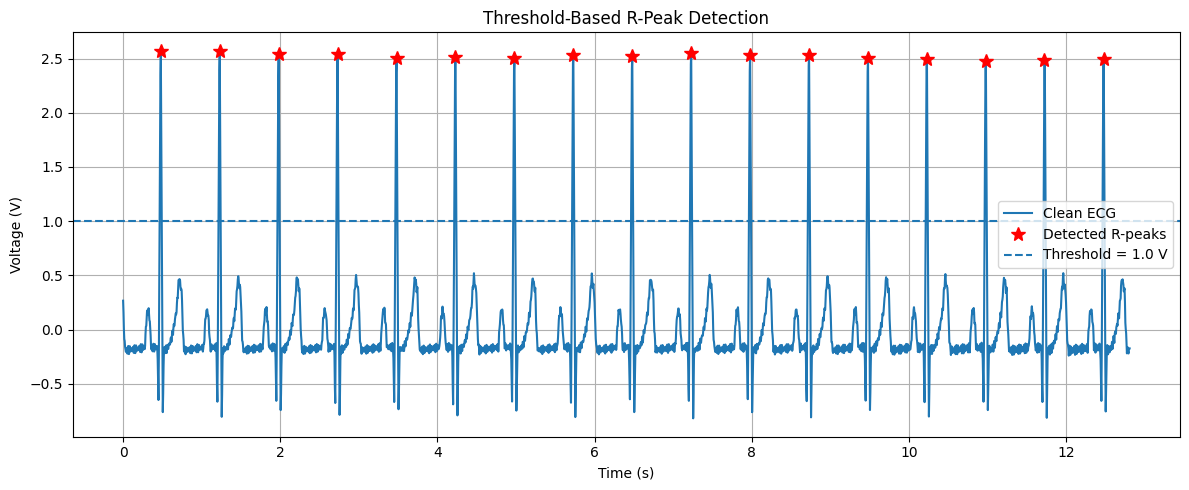


Explanation:

Since the R-peaks in the clean ECG clearly rise beyond this threshold while the majority of the waveform stays below it, a threshold of 1.0 V was chosen.

To avoid counting several points from the same QRS complex as distinct R-peaks, a minimum spacing of 0.4 s was applied.



FINAL ANSWER SUMMARY


In [17]:
# ============================================================
# PART B
# QUIZ CHALLENGE
# -------------------------------------------------------------
# PROBLEM 4
# THRESHOLD-BASED R-PEAK DETECTION

print("\n\n" + "=" * 70)
print("PROBLEM 4: R-PEAK DETECTION")
print("=" * 70)

time = data4["Timestamp"].to_numpy()
voltage = data4["Voltage"].to_numpy()

threshold = 1.0
print(
    f"\nThreshold selected: "
    f"{threshold:.2f} V"
)
above_threshold = voltage > threshold
regions = []
start = None

for i in range(len(above_threshold)):
    if above_threshold[i] and start is None:
        start = i
    elif not above_threshold[i] and start is not None:
        regions.append(
            (start, i - 1)
        )
        start = None
if start is not None:
    regions.append(
        (
            start,
            len(above_threshold) - 1
        )
    )
candidate_peaks = []
for start, end in regions:
    peak_index = (
        start
        + np.argmax(
            voltage[start:end + 1]
        )
    )
    candidate_peaks.append(
        peak_index
    )

minimum_distance = 0.4
r_peaks = []
for peak in candidate_peaks:
    if len(r_peaks) == 0:
        r_peaks.append(peak)
    else:
        time_difference = (
            time[peak]
            - time[r_peaks[-1]]
        )
        if time_difference >= minimum_distance:

            r_peaks.append(peak)

print(
    f"Minimum peak separation: "
    f"{minimum_distance:.2f} s"
)
print(
    f"Total R-peaks detected: "
    f"{len(r_peaks)}"
)
print("\nDetected R-peak times:")
for number, peak in enumerate(
    r_peaks,
    start=1
):
    print(
        f"R-peak {number:2d}: "
        f"{time[peak]:.3f} s"
    )
plt.figure(figsize=(12, 5))
plt.plot(
    time,
    voltage,
    label="Clean ECG"
)
plt.plot(
    time[r_peaks],
    voltage[r_peaks],
    "r*",
    markersize=10,
    label="Detected R-peaks"
)
plt.axhline(
    threshold,
    linestyle="--",
    label=f"Threshold = {threshold:.1f} V"
)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")

plt.title(
    "Threshold-Based R-Peak Detection"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("\nExplanation:")
print("""
Since the R-peaks in the clean ECG clearly rise beyond this threshold while the majority of the waveform stays below it, a threshold of 1.0 V was chosen.

To avoid counting several points from the same QRS complex as distinct R-peaks, a minimum spacing of 0.4 s was applied.
""")
print("\n\n" + "=" * 70)
print("FINAL ANSWER SUMMARY")
print("=" * 70)

In [18]:
# ============================================================
# EXTRA CELL: SAVE ALL GRAPHS
import os
import matplotlib.pyplot as plt

output_folder = r"C:\Users\Therm\OneDrive\Downloads\BCI 1 Pro\BSP_Graphs"
os.makedirs(output_folder, exist_ok=True)

print("=" * 70)
print("SAVING GRAPHS")
print("=" * 70)

# ============================================================
# GRAPH 1 - FILE 1
plt.figure(figsize=(10, 4))
plt.plot(
    data1["Timestamp"],
    data1["Voltage"]
)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("File 1 - 50 uV Sine Wave")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(output_folder, "01_File1_50uV_Sine_Wave.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# ============================================================
# GRAPH 2 - FILE 2
plt.figure(figsize=(10, 4))
plt.plot(
    data2["Timestamp"],
    data2["Voltage"]
)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("File 2 - 1 mV Sine Wave")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(output_folder, "02_File2_1mV_Sine_Wave.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# ============================================================
# GRAPH 3 - FILE 3
plt.figure(figsize=(10, 4))
plt.plot(
    data3["Timestamp"],
    data3["Voltage"]
)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("File 3 - ECG with Noise")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(output_folder, "03_File3_ECG_Noisy.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# ============================================================
# GRAPH 4 - FILE 4
plt.figure(figsize=(10, 4))
plt.plot(
    data4["Timestamp"],
    data4["Voltage"]
)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("File 4 - Clean ECG")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(output_folder, "04_File4_ECG_Clean.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# ============================================================
# GRAPH 5 - SINE WAVE OVERLAY

plt.figure(figsize=(12, 5))
plt.plot(
    data1["Timestamp"],
    data1["Voltage"],
    label="File 1 - 50 uV sine wave"
)
plt.plot(
    data2["Timestamp"],
    data2["Voltage"],
    label="File 2 - 1 mV sine wave"
)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Comparison of Sine-Wave Signals")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(output_folder, "05_Sine_Wave_Overlay.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# ============================================================
# GRAPH 6 - ECG NOISY VS CLEAN
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)
axes[0].plot(
    data3["Timestamp"],
    data3["Voltage"]
)
axes[0].set_title("File 3 - ECG with Noise")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Voltage (V)")
axes[0].grid(True)
axes[1].plot(
    data4["Timestamp"],
    data4["Voltage"]
)
axes[1].set_title("File 4 - Clean ECG")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Voltage (V)")
axes[1].grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(output_folder, "06_ECG_Noisy_vs_Clean.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# ============================================================
# GRAPH 7 - R-PEAK DETECTION
plt.figure(figsize=(12, 5))
plt.plot(
    time,
    voltage,
    label="Clean ECG"
)
plt.plot(
    time[r_peaks],
    voltage[r_peaks],
    "r*",
    markersize=10,
    label="Detected R-peaks"
)
plt.axhline(
    threshold,
    linestyle="--",
    label=f"Threshold = {threshold:.1f} V"
)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Threshold-Based R-Peak Detection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(output_folder, "07_R_Peak_Detection.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("\nAll graphs have been saved successfully!")
print(f"\nFolder:")
print(output_folder)

print("\nSaved files:")

for filename in sorted(os.listdir(output_folder)):
    print(" -", filename)

print("\n" + "=" * 70)

SAVING GRAPHS

All graphs have been saved successfully!

Folder:
C:\Users\Therm\OneDrive\Downloads\BCI 1 Pro\BSP_Graphs

Saved files:
 - 01_File1_50uV_Sine_Wave.png
 - 02_File2_1mV_Sine_Wave.png
 - 03_File3_ECG_Noisy.png
 - 04_File4_ECG_Clean.png
 - 05_Sine_Wave_Overlay.png
 - 06_ECG_Noisy_vs_Clean.png
 - 07_R_Peak_Detection.png



In [19]:
# ------------------------------------------------------------
# PROBLEM 1
# ------------------------------------------------------------
print("\nPROBLEM 1")
print("-" * 70)
for name, data in datasets.items():
    print(
        f"{name}: "
        f"{len(data)} data points, "
        f"1 channel, "
        f"{sampling_frequencies[name]:.0f} Hz"
    )

print("\nTimestamp unit: seconds (s)")
print("Voltage unit: Volts (V)")

# ------------------------------------------------------------
# PROBLEM 2
# ------------------------------------------------------------

print("\nPROBLEM 2")
print("-" * 70)

print(
    summary_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ------------------------------------------------------------
# PROBLEM 3
# ------------------------------------------------------------

print("\nPROBLEM 3")
print("-" * 70)

print(
    "The noisy ECG contains additional rapid fluctuations "
    "and irregular variations."
)

print(
    "The clean ECG has a smoother waveform and clearer "
    "R-peaks."
)


# ------------------------------------------------------------
# PROBLEM 4
# ------------------------------------------------------------

print("\nPROBLEM 4")
print("-" * 70)

print(
    f"Threshold: {threshold:.2f} V"
)

print(
    f"Minimum peak separation: "
    f"{minimum_distance:.2f} s"
)

print(
    f"Total R-peaks detected: "
    f"{len(r_peaks)}"
)


print("\n" + "=" * 70)
print("END OF PROBLEM SET")
print("=" * 70)


PROBLEM 1
----------------------------------------------------------------------
File 1 - 50 uV sine wave: 6012 data points, 1 channel, 500 Hz
File 2 - 1 mV sine wave: 7626 data points, 1 channel, 500 Hz
File 3 - ECG with noise: 2376 data points, 1 channel, 200 Hz
File 4 - ECG clean: 2563 data points, 1 channel, 200 Hz

Timestamp unit: seconds (s)
Voltage unit: Volts (V)

PROBLEM 2
----------------------------------------------------------------------
                    File  Minimum (V)  Maximum (V)  Mean (V)  Standard Deviation (V)
File 1 - 50 uV sine wave    -0.128784     0.131836  0.001598                0.089655
 File 2 - 1 mV sine wave    -2.520752     2.530518 -0.005032                1.785869
 File 3 - ECG with noise    -1.296082     2.960205 -0.001022                0.562102
      File 4 - ECG clean    -0.818176     2.572021  0.001902                0.434829

PROBLEM 3
----------------------------------------------------------------------
The noisy ECG contains additional ra